In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

from pathlib import Path

In [6]:
# Paths
data_path = Path.cwd().parent / 'Data'

In [7]:
dna_json = data_path / 'unit_test' / 'dnas.json'
test_data = data_path / 'pre_training' / 'test' / 'dnas_638888964287547287.json'


In [8]:
with open(dna_json) as f:
    dnas = json.load(f)

print('Number of DNA files:', len(dnas))

Number of DNA files: 622


## DNA Structure
- id: unique identifier
- set: part of which collection (folder)
- type: type of DNA (Drumbeats, RhythmGuitars, SoloGuitars, Empty) **(irrelevant)**
- authorData: author information
- StyleTags: keywords describing dna
- originalMidifileReference: path to original midi file **(irrelevant)**
- AudioFiles: in case of non midi **(irrelevant)**
- IsTimeBased: relevant for audio files **(irrelevant)**
- Bpm: beats per minute
- BpmRangeStart: start of bpm range where this pattern would still make sense (20% slower) -> number was arbitrarily chosen
- BpmRangeEnd: end of bpm range where this pattern would still make sense (20% faster) -> number was arbitrarily chosen
- GridResolution: musical grid resolution e.g. 16th, 8th, 4th notes used to quantize the midi file (Enum value)
- GridFactor: subdivision of the grid resolution based on quarter notes e.g. 8th resolution = 2, 16th resolution = 4, 16-triplet = 6,...
- UnitLengthMs: 1.0 * 60000 / (Bpm * GridFactor)
- BasicKey: key of the midi file **(irrelevant)**
- BasicScale: scale of the midi file **(irrelevant)**
- Numerator: numerator of the time signature
- Denominator: denominator of the time signature
- TicksPerQuarterNote: number of ticks per quarter note
- IsTernary: triplet grid active
- NumberOfBars: number of bars in the midi file
- TicksPerGridUnit: number of ticks per grid unit
- Description: description of the midi file
- FillStartTicks: start ticks where the fill starts
- DNAUnits: list of DNA units
- MusicEvents: Midi representation of the midi file

DNAUnit:

    public class DNAUnit
    {
        public int Value { get; set; } = 0;
        public int? ExcludeValue { get; set; } = null;
        public bool Wildcard { get; set; } = false;

        public int AvgOffsetTicks { get; set; } = 0;
        public int TransposeInstruction { get; set; } = 0;
        public double AvgVelocity { get; set; } = 1.0;

        public Dictionary<int, int> OffsetTicksPerValuePart { get; set; } = new Dictionary<int, int>();
        public Dictionary<int, double> VelocityPerValuePart { get; set; } = new Dictionary<int, double>();

        public bool IsEmpty { get; set; } = false;
        public bool ContinuingLastUnit { get; set; } = false;


    }

In [9]:
dna1 = dnas[0]

for unit in dna1['DNAUnits']:
    if unit['IsEmpty'] == False:
        print(unit['OffsetTicksPerValuePart'])

{'2': 0}
{'2': 0}
{'1': 0}
{'1': 41}
{'1': 6}
{'4': 48, '1': -42}
{'2': 2}
{'2': 1}
{'1': -2}
{'1': 39}
{'1': 4}
{'4': 46, '1': -44}
{'2': -2}
{'1': 1, '32': 1}
{'4': 2}
{'4': 38, '1': -42}
{'1': 2}
{'1': 2}
{'2': 7}
{'1': -5}
{'4': -1}
{'1': 8}


In [16]:
dna1['TicksPerGridUnit']

120

In [10]:
for dna in dnas:
    for unit in dna['DNAUnits']:
        if unit['ContinuingLastUnit'] == True:
            print('Used')
            break

In [11]:

for unit in dna1['DNAUnits']:
    print(unit['VelocityPerValuePart'])

{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{'2': 1}
{'2': 1}
{'1': 1}
{'1': 1}
{'1': 1}
{'4': 1, '1': 1}
{'2': 1}
{'2': 0.9763779527559056}
{'1': 1}
{'1': 1}
{'1': 1}
{'4': 1, '1': 1}
{'2': 1}
{}
{}
{}
{'1': 1, '32': 1}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{'4': 1}
{'4': 0.937007874015748, '1': 0.905511811023622}
{'1': 1}
{}
{'1': 1}
{}
{'2': 1}
{}
{'1': 1}
{}
{'4': 1}
{}
{'1': 1}


In [12]:
for unit in dna1['DNAUnits']:
    print(bin(unit['Value']))

0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b10
0b10
0b1
0b1
0b1
0b101
0b10
0b10
0b1
0b1
0b1
0b101
0b10
0b0
0b0
0b0
0b100001
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b0
0b100
0b101
0b1
0b0
0b1
0b0
0b10
0b0
0b1
0b0
0b100
0b0
0b1


In [13]:
instrumentValues = {'None': 0, 'Kick' : 1 << 0, 'Snare' : 1 << 1,'Toms' : 1 << 2, 'HHClose': 1 << 3, 'HHOpen' : 1 << 4, 'Ride' : 1 << 5, 'Cymbal' : 1 << 6}
# switch keys and values\
instrumentValues = {v: k for k, v in instrumentValues.items()}
instrumentValues

{0: 'None',
 1: 'Kick',
 2: 'Snare',
 4: 'Toms',
 8: 'HHClose',
 16: 'HHOpen',
 32: 'Ride',
 64: 'Cymbal'}

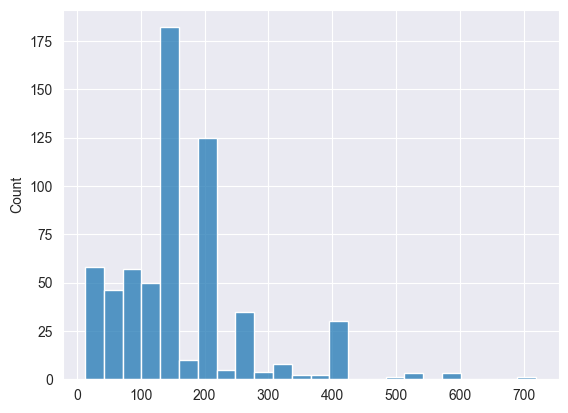

162.54823151125402
102.62387270652
143.0
719
13
87


In [14]:
import numpy as np

dna_unit_lengths = np.zeros((len(dnas)), dtype=int)

for i, dna in enumerate(dnas):
    dna_unit_lengths[i] = len(dna['DNAUnits'])

count_greater = [i for i in dna_unit_lengths if i > 256]

sns.histplot(dna_unit_lengths)
plt.show()
print(np.mean(dna_unit_lengths))
print(np.std(dna_unit_lengths))
print(np.median(dna_unit_lengths))
print(np.max(dna_unit_lengths))
print(np.min(dna_unit_lengths))
print(len(count_greater))


In [15]:
with open(test_data) as f:
    test_dnas = json.load(f)

len(test_dnas)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\minem\\PycharmProjects\\ITS-M\\Master\\GroovePal\\Data\\pre_training\\test\\dnas_638888964287547287.json'

In [12]:
test_dnas[0].keys()

dict_keys(['DNA_ID', 'DNASet', 'DNAType', 'AuthorData', 'StyleTags', 'OriginalMidiFileReference', 'AudioFiles', 'IsTimeBased', 'DNAUnits', 'MusicEvents', 'Bpm', 'BpmRangeStart', 'BpmRangeEnd', 'GridResolution', 'GridFactor', 'UnitLengthMs', 'BasicKey', 'BasicScale', 'Numerator', 'Denominator', 'TicksPerQuarterNote', 'IsTernary', 'NumberOfBars', 'TicksPerGridUnit', 'Description', 'FillStartTicks'])

In [13]:
test_dnas[0]['DNAUnits'][0].keys()

dict_keys(['Value', 'ExcludeValue', 'Wildcard', 'AvgOffsetTicks', 'TransposeInstruction', 'AvgVelocity', 'OffsetTicksPerValuePart', 'VelocityPerValuePart', 'IsEmpty', 'ContinuingLastUnit'])

In [14]:
# Define the top-level fields you care about
fields_to_check = [
    'Bpm', 'NumberOfBars', 'GridFactor', 'TicksPerQuarterNote',
    'TicksPerGridUnit', 'Numerator', 'Denominator', 'IsTernary'
]

# Track missing field counts and problematic DNA entries
missing_summary = {field: 0 for field in fields_to_check}
missing_dnas = []

for dna in dnas:
    missing_fields = []
    for field in fields_to_check:
        if field not in dna or dna[field] is None or dna[field] == '':
            missing_summary[field] += 1
            missing_fields.append(field)

    if missing_fields:
        missing_dnas.append((dna.get('DNA_ID', 'Unknown_ID'), missing_fields, dna))

# Print summary counts
print("Missing top-level field summary:")
for field, count in missing_summary.items():
    print(f"  {field}: {count}")

# Print examples
print(f"\nFound {len(missing_dnas)} DNA entries with missing fields.\n")

for i, (dna_id, fields, dna_entry) in enumerate(missing_dnas[:5]):
    print(f"DNA_ID: {dna_id}")
    print(f"Missing Fields: {fields}")
    print(json.dumps(dna_entry, indent=2))
    print('-' * 60)

if len(missing_dnas) > 5:
    print(f"...and {len(missing_dnas) - 5} more entries with missing values.")

Missing top-level field summary:
  Bpm: 0
  NumberOfBars: 0
  GridFactor: 0
  TicksPerQuarterNote: 0
  TicksPerGridUnit: 0
  Numerator: 0
  Denominator: 0
  IsTernary: 0

Found 0 DNA entries with missing fields.



In [22]:
flat_data = []

for dna in test_dnas:
    units = dna.get('DNAUnits', [])

    flat_data.append({
        'DNA_ID': dna['DNA_ID'],
        'Bpm': dna['Bpm'],
        'Offsets': [u['AvgOffsetTicks'] for u in units],
        'Values': [u['Value'] for u in units],
        'Velocities': [u['AvgVelocity'] for u in units],
        'NumberOfBars': dna['NumberOfBars'],
        'GridFactor': dna['GridFactor'],
        'TicksPerQuarterNote': dna['TicksPerQuarterNote'],
        'TicksPerGridUnit': dna['TicksPerGridUnit'],
        'Numerator': dna['Numerator'],
        'Denominator': dna['Denominator'],
        'IsTernary': dna['IsTernary'],
        'UnitCount': len(units)
    })

df = pd.DataFrame(flat_data)
print(f"Total rows in DataFrame: {len(df)}")  # Should be 9526

Total rows in DataFrame: 9526


In [26]:
df.head()

,DNA_ID,Bpm,Offsets,Values,Velocities,NumberOfBars,GridFactor,TicksPerQuarterNote,TicksPerGridUnit,Numerator,Denominator,IsTernary,UnitCount
0,giga_0,100,"[0, -9, 0, 13, 2, -8, 0, 12, 2, -8, 0, 13, 0, ...","[3, 2, 0, 3, 2, 2, 0, 3, 2, 2, 0, 2, 2, 2, 0, 2]","[0.9763779527559056, 0.5590551181102362, 0, 0....",1,4,120,30,4,4,False,16
1,giga_1,150,"[0, 8, 27, 2, 13, 16, -2, 1, 13, 15, 29, 4, -4...","[4, 4, 4, 1, 5, 5, 4, 1, 5, 5, 4, 1, 5, 5, 4, ...","[0.7795275590551181, 0.8503937007874016, 0.728...",1,4,240,60,7,4,False,27
2,giga_10,160,"[0, 0, 0, 0, -6, 0, 0, 0, -3, 0, 0, 0, 8, 0, 7...","[5, 0, 0, 0, 33, 0, 0, 0, 34, 0, 0, 0, 32, 0, ...","[0.9448818897637795, 0, 0, 0, 0.88582677165354...",2,4,240,60,3,4,False,47
3,giga_100,60,"[0, 20, 0, 20, 30, 0, 0, 0, 30, 0, 30, 0, 0, 0...","[2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2]","[0.46062992125984253, 0.6535433070866141, 0.64...",1,4,240,60,4,4,False,16
4,giga_1000,120,"[-1, -4, 0, 0, 1, 3, 1, -2, 2, -4, 4, -2, 3, 1...","[7, 4, 6, 4, 6, 6, 7, 4, 7, 4, 6, 4, 6, 4, 7, ...","[0.8320209973753281, 0.6692913385826772, 0.713...",4,4,480,120,4,4,False,64


In [23]:
nan_rows = df[df.isna().any(axis=1)]
print(f"Found {len(nan_rows)} rows with NaN values.")
nan_rows

Found 0 rows with NaN values.


,DNA_ID,Bpm,Offsets,Values,Velocities,NumberOfBars,GridFactor,TicksPerQuarterNote,TicksPerGridUnit,Numerator,Denominator,IsTernary,UnitCount


### BPM Distribution

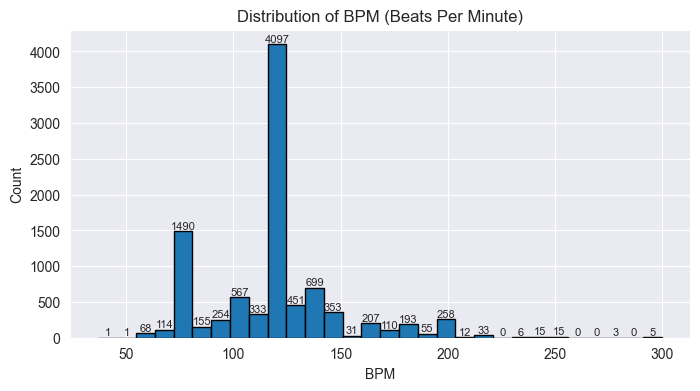

In [24]:
plt.figure(figsize=(8, 4))
counts, bins, patches = plt.hist(df['Bpm'].dropna(), bins=30, edgecolor='black')

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    plt.text((bin_left + bin_right) / 2, count, int(count), ha='center', va='bottom', fontsize=8)

plt.title("Distribution of BPM (Beats Per Minute)")
plt.xlabel("BPM")
plt.ylabel("Count")
plt.grid(True)
plt.show()

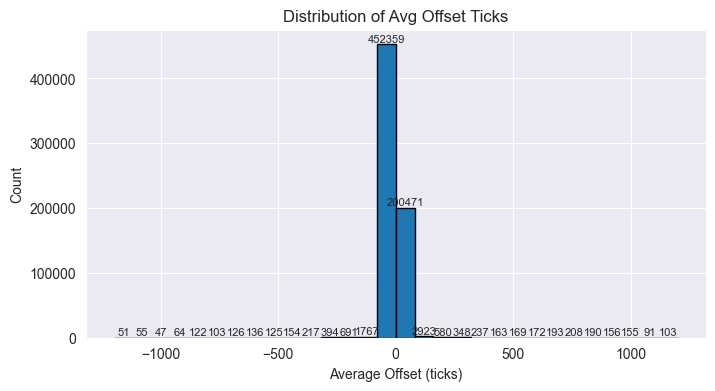

In [18]:
offsets = [offset for sublist in df['Offsets'].dropna() for offset in sublist]

plt.figure(figsize=(8, 4))
counts, bins, patches = plt.hist(offsets, bins=30, edgecolor='black')

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    plt.text((bin_left + bin_right) / 2, count, int(count), ha='center', va='bottom', fontsize=8)

plt.title("Distribution of Avg Offset Ticks")
plt.xlabel("Average Offset (ticks)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

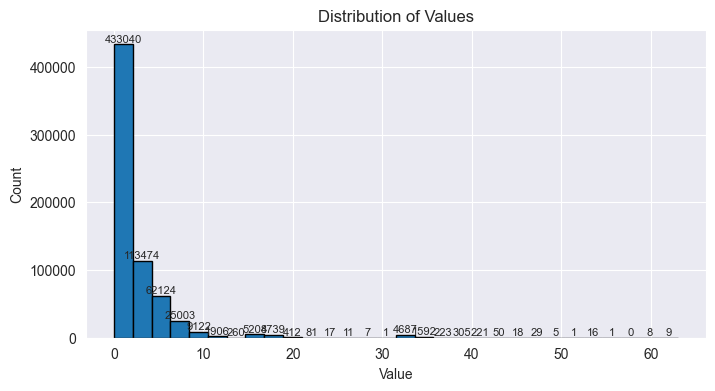

In [19]:
values = [val for sublist in df['Values'].dropna() for val in sublist]

plt.figure(figsize=(8, 4))
counts, bins, patches = plt.hist(values, bins=30, edgecolor='black')

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    plt.text((bin_left + bin_right) / 2, count, int(count), ha='center', va='bottom', fontsize=8)

plt.title("Distribution of Values")
plt.xlabel("Value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

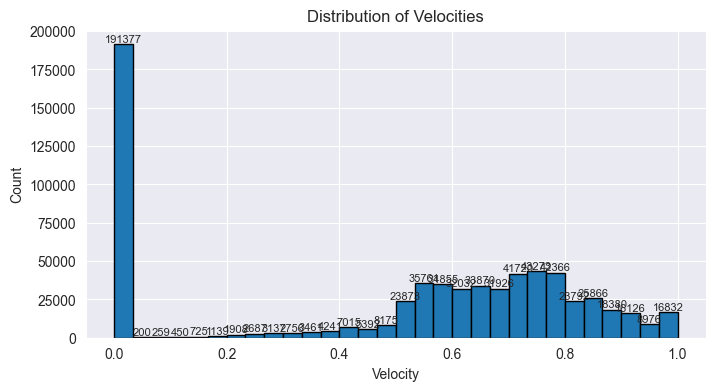

In [25]:
values = [val for sublist in df['Velocities'].dropna() for val in sublist]

plt.figure(figsize=(8, 4))
counts, bins, patches = plt.hist(values, bins=30, edgecolor='black')

for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    plt.text((bin_left + bin_right) / 2, count, int(count), ha='center', va='bottom', fontsize=8)

plt.title("Distribution of Velocities")
plt.xlabel("Velocity")
plt.ylabel("Count")
plt.grid(True)
plt.show()

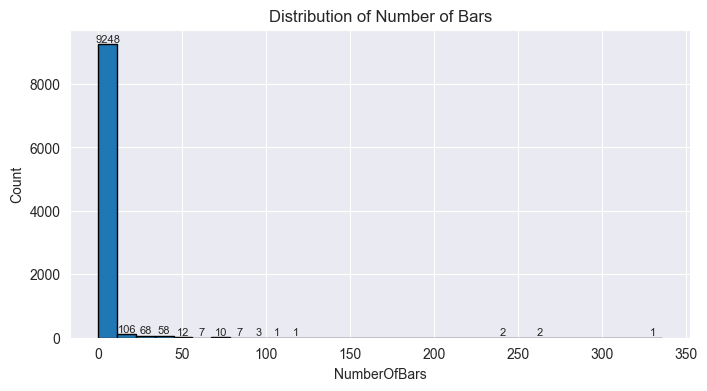

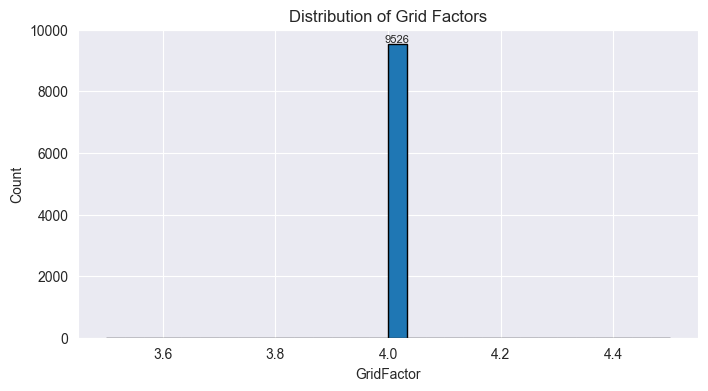

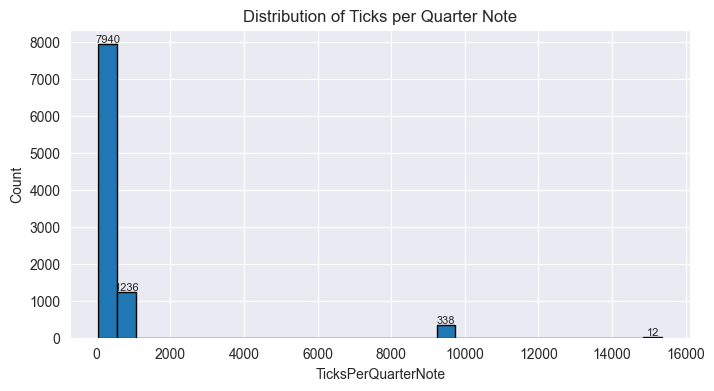

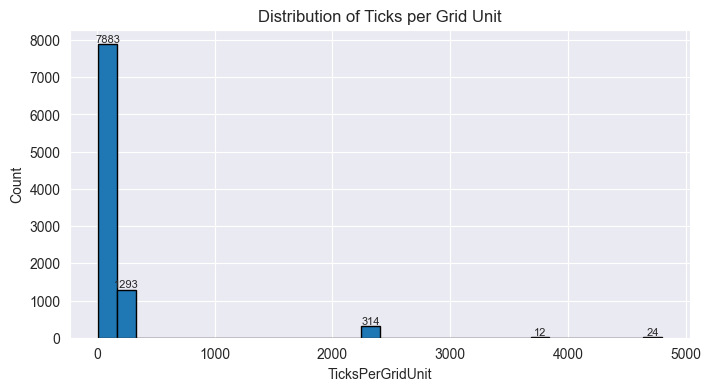

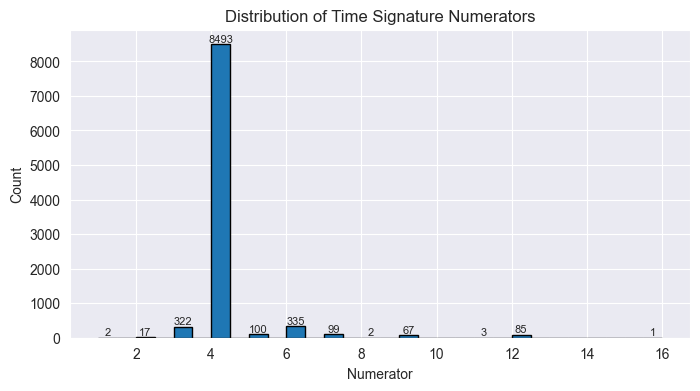

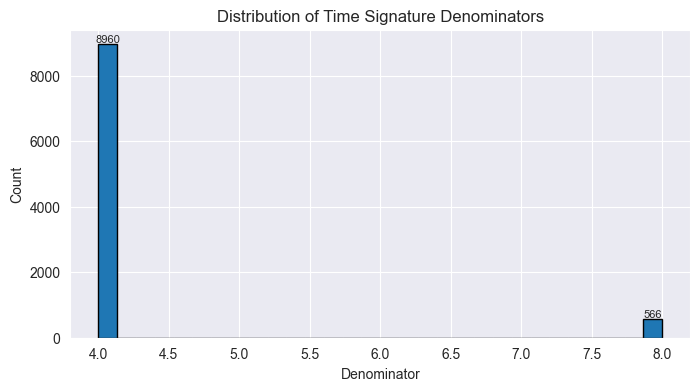

In [20]:
features = [
    'NumberOfBars',
    'GridFactor',
    'TicksPerQuarterNote',
    'TicksPerGridUnit',
    'Numerator',
    'Denominator',
]

titles = {
    'NumberOfBars': "Distribution of Number of Bars",
    'GridFactor': "Distribution of Grid Factors",
    'TicksPerQuarterNote': "Distribution of Ticks per Quarter Note",
    'TicksPerGridUnit': "Distribution of Ticks per Grid Unit",
    'Numerator': "Distribution of Time Signature Numerators",
    'Denominator': "Distribution of Time Signature Denominators",
}

for feature in features:
    plt.figure(figsize=(8, 4))
    data = df[feature].dropna()
    counts, bins, patches = plt.hist(data, bins=30, edgecolor='black')

    for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
        if count > 0:
            plt.text((bin_left + bin_right) / 2, count, int(count), ha='center', va='bottom', fontsize=8)

    plt.title(titles[feature])
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

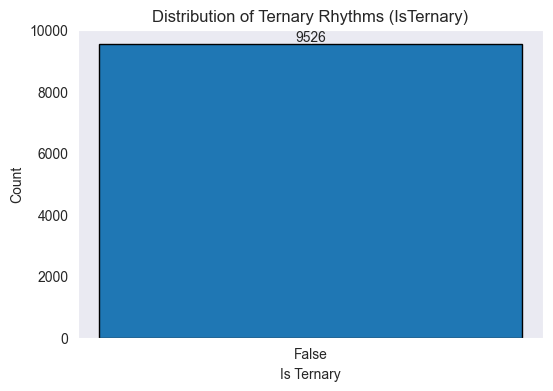

In [21]:
plt.figure(figsize=(6, 4))

# Convert boolean values to string for labeling
bool_counts = df['IsTernary'].dropna().value_counts()
labels = [str(val) for val in bool_counts.index]
bars = plt.bar(labels, bool_counts.values, edgecolor='black')

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, int(height), ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Ternary Rhythms (IsTernary)")
plt.xlabel("Is Ternary")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()